In [1]:
import hoda
import tensorly as tl
import mne


mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [32]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = GreedyBTTDA(
    max_blocks=16,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-20,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lobpcg',
        taper=False,
        extra_train_info=False,
        verbose=False,
       
    ),
    verbose=True,
    extra_train_info=True,
    gs_params=dict(n_jobs=5),
    
)
#%env PYTHONWARNINGS=ignore
bttda.fit(X,y)

Fitting block 1/1...
Fitting block 2/2...
Fitting block 3/3...
Fitting block 4/4...
Fitting block 5/5...
Fitting block 6/6...
Fitting block 7/7...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(


Fitting block 8/8...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(


Fitting block 9/9...


...

/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(


Fitting block 14/14...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim', falling back to lanczos solver with SPD constraint
  warnings.warn(


Fitting block 15/15...
Fitting block 16/16...


GreedyBTTDA(extra_train_info=True,
            gs_params={'n_jobs': 5, 'refit': True, 'scoring': 'roc_auc'},
            hoda_params={'extra_train_info': False, 'init': 'svd',
                         'max_iter': 64, 'obj': 'rt', 'rank': None,
                         'shrinkage': 'lw', 'solver': 'lobpcg', 'taper': False,
                         'toeplitz': (1,), 'tol': 1e-20, 'verbose': False},
            max_blocks=16, verbose=True)

In [33]:
bttda.train_info_

,rank,mse,score
block,,,
1,"(8, 8)",5.699153e-11,0.840069
2,"(1, 1)",5.182714e-11,0.853608
3,"(1, 1)",4.734578e-11,0.853206
4,"(1, 1)",4.311806e-11,0.853253
5,"(1, 1)",4.313067e-11,0.853476
6,"(1, 1)",3.934220e-11,0.855547
7,"(1, 1)",3.936130e-11,0.855120
8,"(1, 1)",3.611106e-11,0.855718
9,"(7, 7)",3.918155e-11,0.855233


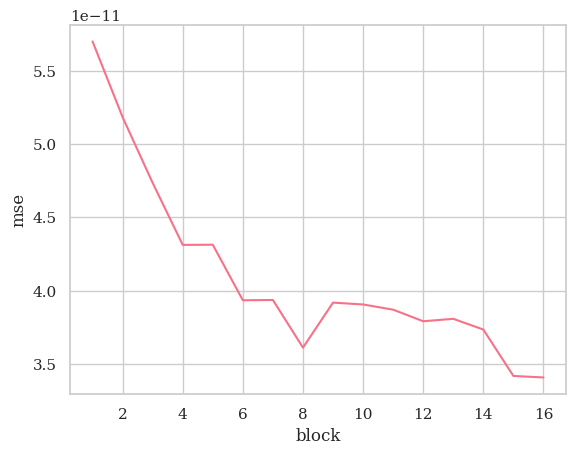

<Axes: xlabel='block', ylabel='score'>

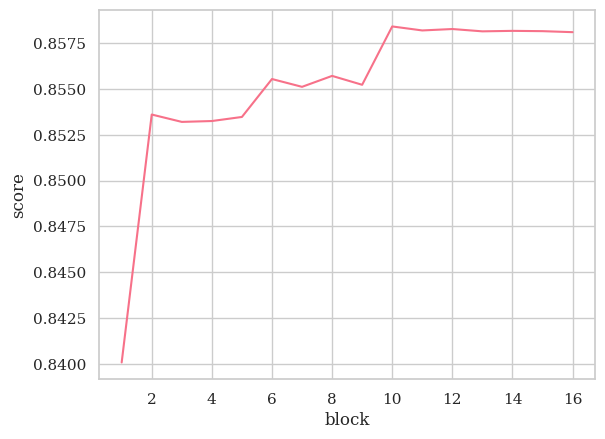

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=bttda.train_info_, x='block', y='mse')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='score')




In [ ]:
Xt = bttda.transform(X)

In [ ]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='black')


In [ ]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [ ]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

In [ ]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [ ]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

In [ ]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


In [ ]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)